### Working with MNIST Dataset to practice classsification problem

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
mnist = fetch_openml(name='mnist_784', version=1)

In [21]:
df = pd.DataFrame(mnist['data'])
y = mnist['target'].astype(int)

In [22]:
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
df.iloc[9,:]

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 9, Length: 784, dtype: int64

In [24]:
import matplotlib.pyplot as plt
def draw_num(index):
    index_modified = df.iloc[index,:].to_numpy().reshape(28,28)
    plt.imshow(index_modified,cmap = 'binary')
    plt.axis('off')
    plt.show()
    print('The predicted value is: ', y[index])

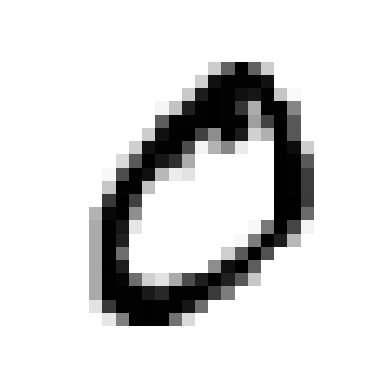

The predicted value is:  0


In [25]:
draw_num(1)

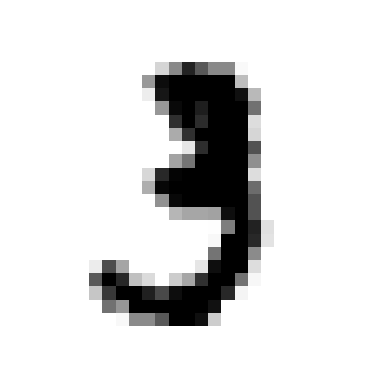

The predicted value is:  3


In [26]:
draw_num(10
         )

In [27]:
[i for i in df.select_dtypes(include = 'object').columns]

[]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(df, y,test_size=0.2,random_state=42)

In [29]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56000 entries, 47339 to 15795
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 335.4 MB


In [30]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14000 entries, 46730 to 63452
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 83.8 MB


In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.decomposition import PCA

# Example: keep 95% variance
pca = PCA(n_components=0.95, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (56000, 784)
Reduced shape: (56000, 330)


In [50]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(multi_class='multinomial')

In [51]:
logistic.fit(X_train_pca, y_train)

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [53]:
pred = logistic.predict(X_test_pca)
from sklearn.metrics import accuracy_score
print("Accuracy: ", accuracy_score(y_test, pred))

Accuracy:  0.9215714285714286


In [57]:
import numpy as np
val, count = np.unique(y_train, return_counts = True)
print("Value: ", val)
print("Count: ", count)

Value:  [0 1 2 3 4 5 6 7 8 9]
Count:  [5560 6277 5610 5708 5529 5040 5480 5790 5468 5538]


In [58]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred)

array([[1296,    1,    6,    0,    2,   13,   14,    3,    5,    3],
       [   0, 1554,    3,   10,    3,    7,    1,    5,   16,    1],
       [   5,   17, 1249,   16,   15,    8,   18,   17,   27,    8],
       [   7,   11,   37, 1279,    2,   39,    4,   17,   22,   15],
       [   4,    3,    7,    3, 1195,    5,   14,    7,    5,   52],
       [   7,   11,    7,   41,   14, 1123,   19,    2,   40,    9],
       [   5,    5,   15,    1,   14,   15, 1334,    4,    3,    0],
       [   5,    4,   19,    4,    9,    5,    0, 1419,    1,   37],
       [  11,   27,   14,   41,    5,   47,    8,    7, 1178,   19],
       [   6,   10,    5,   15,   38,    4,    0,   51,   16, 1275]])